# Fruit & Vegetable Disease Classifier — Final Production Notebook

Dataset: [Kaggle Fruits and Vegetables Disease](https://www.kaggle.com/datasets/muhammadkhalid/fruits-and-vegetables-disease) (28 classes, 5GB)

Strategy: EfficientNetV2S + tf.data pipeline + mixed precision + 2-phase training

> Run on Kaggle (free T4) or Google Colab

## 0. Setup

In [2]:
!pip install -q matplotlib seaborn scikit-learn pillow

import os, random, warnings, json, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from pathlib import Path
from PIL import Image as PILImage
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, callbacks, mixed_precision
from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input as effv2_preprocess

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

print(f'TensorFlow: {tf.__version__}')
print(f'GPU: {tf.config.list_physical_devices("GPU")}')

mixed_precision.set_global_policy('mixed_float16')
print(f'Precision policy: {mixed_precision.global_policy().compute_dtype}')

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

MODEL_NAME = 'EfficientNetV2S'

2026-05-21 19:50:20.177960: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779393020.407368      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779393020.473405      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779393021.009703      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779393021.009750      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779393021.009753      57 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Precision policy: float16


## 1. Config

In [3]:
DATA_DIR   = Path('/kaggle/input/datasets/muhammad0subhan/fruit-and-vegetable-disease-healthy-vs-rotten/Fruit And Vegetable Diseases Dataset')
TRAIN_DIR  = DATA_DIR / 'train' if (DATA_DIR / 'train').exists() else DATA_DIR
TEST_DIR   = DATA_DIR / 'test'  if (DATA_DIR / 'test').exists()  else None
MODEL_DIR  = Path('/kaggle/working/models')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# ── Key changes vs original EfficientNet notebook ──────────────────────
IMG_SIZE   = (224, 224)   # EfficientNetV2S native resolution
BATCH      = 32
EPOCHS_FE  = 10            # ← reduced from 15 (EarlyStopping handles the rest)
EPOCHS_FT  = 8             # ← reduced from 25; cosine LR + EarlyStopping
VAL_SPLIT  = 0.20          # ← increased from 0.15 for better generalisation signal
TEST_SPLIT = 0.10
LR_FE      = 1e-3
LR_FT      = 1e-5          # ← lowered from 5e-5 (gentler fine-tuning)
UNFREEZE   = 30            # ← drastically reduced from 100 (prevents catastrophic forgetting)

print(f'Train dir: {TRAIN_DIR}  exists={TRAIN_DIR.exists()}')
print(f'Config: IMG={IMG_SIZE}, BATCH={BATCH}, LR_FE={LR_FE}, LR_FT={LR_FT}, UNFREEZE={UNFREEZE}')

Train dir: /kaggle/input/datasets/muhammad0subhan/fruit-and-vegetable-disease-healthy-vs-rotten/Fruit And Vegetable Diseases Dataset  exists=True
Config: IMG=(224, 224), BATCH=32, LR_FE=0.001, LR_FT=1e-05, UNFREEZE=30


In [10]:
# (PIL scan moved to after FILTERED_DIR is created — see cell below c6)

Bad files found: 0


In [11]:
# (removal step moved — see after FILTERED_DIR creation)

Bad files removed.


## 2. Dataset Exploration

I0000 00:00:1779393263.337502      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779393263.343801      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Corrupt / unreadable files found: 10
  REMOVING: /kaggle/working/filtered_dataset/Apple__Rotten/rottenApple (4).webp
  REMOVING: /kaggle/working/filtered_dataset/Apple__Rotten/rottenApple (2).webp
  REMOVING: /kaggle/working/filtered_dataset/Apple__Rotten/rottenApple (1).webp
  REMOVING: /kaggle/working/filtered_dataset/Apple__Rotten/rottenApple (3).webp
  REMOVING: /kaggle/working/filtered_dataset/Apple__Rotten/rottenApple (5).webp
  REMOVING: /kaggle/working/filtered_dataset/Banana__Rotten/rottenBanana (3).webp
  REMOVING: /kaggle/working/filtered_dataset/Banana__Rotten/rottenBanana (1).webp
  REMOVING: /kaggle/working/filtered_dataset/Banana__Rotten/rottenBanana (2).webp
  REMOVING: /kaggle/working/filtered_dataset/Banana__Healthy/freshBanana (1).webp
  REMOVING: /kaggle/working/filtered_dataset/Banana__Healthy/freshBanana (422).jpg
Done.
Classes: 8
Total images: 18,479
             class  count
4   Mango__Healthy   1813
2  Banana__Healthy   1998
6  Orange__Healthy   2075
7   Orange

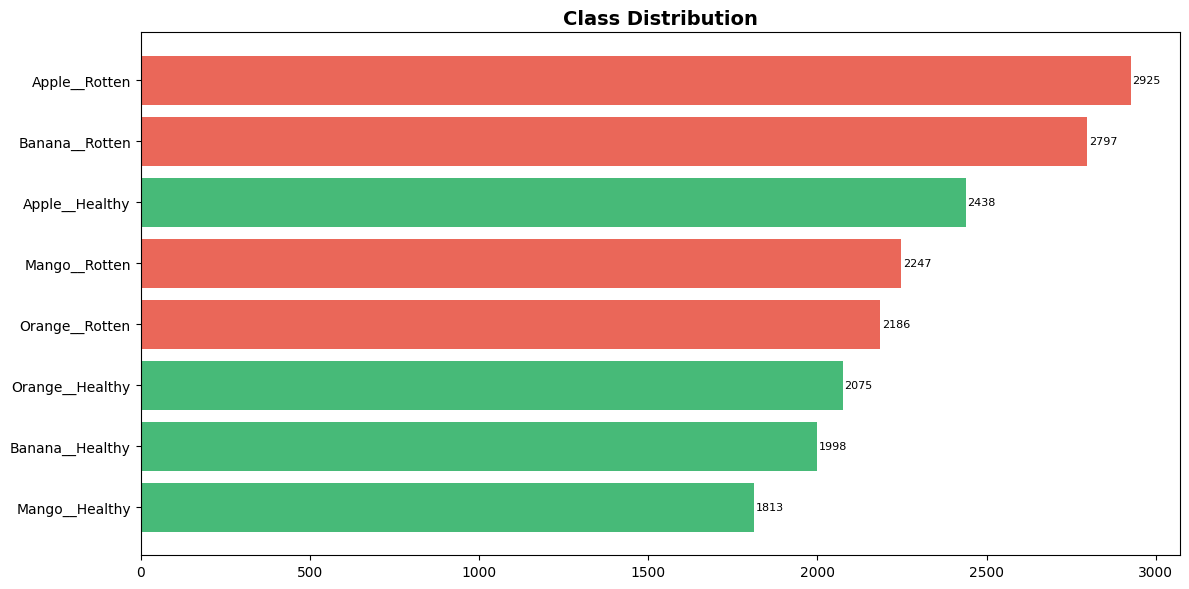

In [4]:
# ===== SELECTED CLASSES (adjust to match your 18k dataset) =====
# Comment out SELECTED_CLASSES and FILTERED_DIR blocks to use ALL classes.
SELECTED_CLASSES = [
    'Apple__Healthy',
    'Apple__Rotten',
    'Banana__Healthy',
    'Banana__Rotten',
    'Orange__Healthy',
    'Orange__Rotten',
    'Mango__Healthy',
    'Mango__Rotten',
]

# ===== CREATE FILTERED DATASET =====
FILTERED_DIR = Path('/kaggle/working/filtered_dataset')
if FILTERED_DIR.exists():
    shutil.rmtree(FILTERED_DIR)
FILTERED_DIR.mkdir(parents=True)

for cls in SELECTED_CLASSES:
    src = TRAIN_DIR / cls
    dst = FILTERED_DIR / cls
    if src.exists():
        shutil.copytree(src, dst)
    else:
        print(f'WARNING: class folder not found: {src}')

# Use FILTERED_DIR as effective train dir from here on
TRAIN_DIR = FILTERED_DIR

# ===== SCAN & REMOVE CORRUPT FILES =====
VALID_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.gif'}
bad_files = []
for path in FILTERED_DIR.rglob('*'):
    if not path.is_file():
        continue
    if path.suffix.lower() not in VALID_EXTS:
        bad_files.append(path)
        continue
    try:
        with PILImage.open(path) as img:
            img.verify()
        with PILImage.open(path) as img:
            img.load()
    except Exception:
        bad_files.append(path)
        continue
    try:
        raw = tf.io.read_file(str(path))
        tf.image.decode_image(raw, channels=3)
    except Exception:
        bad_files.append(path)

print(f'Corrupt / unreadable files found: {len(bad_files)}')
for p in bad_files:
    print(f'  REMOVING: {p}')
    p.unlink()
print('Done.')

# ===== CLASS DISTRIBUTION =====
class_counts = {}
for cls_dir in sorted(FILTERED_DIR.iterdir()):
    if cls_dir.is_dir():
        imgs = [f for f in cls_dir.iterdir() if f.suffix.lower() in VALID_EXTS]
        class_counts[cls_dir.name] = len(imgs)

df_counts = pd.DataFrame(
    list(class_counts.items()), columns=['class', 'count']
).sort_values('count')

CLASS_NAMES = sorted(class_counts.keys())
NUM_CLASSES = len(CLASS_NAMES)
TOTAL_IMGS  = df_counts['count'].sum()

print(f'Classes: {NUM_CLASSES}')
print(f'Total images: {TOTAL_IMGS:,}')
print(df_counts)

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#e74c3c' if 'rotten' in c.lower() else '#27ae60' for c in df_counts['class']]
ax.barh(df_counts['class'], df_counts['count'], color=colors, alpha=0.85)
ax.set_title('Class Distribution', fontsize=14, fontweight='bold')
for i, v in enumerate(df_counts['count']):
    ax.text(v + 5, i, str(v), va='center', fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# Corrupt-file scan already done in the dataset-creation cell above.

In [17]:
# Removal already handled in the dataset-creation cell above.

Removed bad files.


## 3. tf.data Pipeline

> We use `tf.data` instead of the legacy `ImageDataGenerator`. It is ~2x faster on GPU because it prefetches batches on CPU while the GPU trains. On a 5GB dataset this matters a lot.

In [5]:
AUTOTUNE = tf.data.AUTOTUNE

class_to_idx = {name: i for i, name in enumerate(CLASS_NAMES)}
valid_paths, valid_labels = [], []

for cls_name in CLASS_NAMES:
    cls_dir = TRAIN_DIR / cls_name
    label   = class_to_idx[cls_name]
    for p in cls_dir.iterdir():
        if p.suffix.lower() in VALID_EXTS:
            valid_paths.append(str(p))
            valid_labels.append(label)

print(f'Total valid images: {len(valid_paths):,}')

rng = np.random.default_rng(SEED)
idx = rng.permutation(len(valid_paths))
valid_paths  = np.array(valid_paths)[idx].tolist()
valid_labels = np.array(valid_labels)[idx].tolist()

n_total = len(valid_paths)
n_test  = int(n_total * TEST_SPLIT)
n_val   = int(n_total * VAL_SPLIT)
n_train = n_total - n_val - n_test
print(f'Total: {n_total} -> Train: {n_train} | Val: {n_val} | Test: {n_test}')

def safe_load_image(path, label):
    def _load(p, l):
        try:
            raw   = tf.io.read_file(p.numpy().decode())
            image = tf.image.decode_image(raw, channels=3, expand_animations=False)
            image = tf.image.resize(image, IMG_SIZE)
            image = tf.cast(image, tf.float32)
            onehot = tf.one_hot(int(l.numpy()), NUM_CLASSES)
            return image, onehot, tf.constant(True)
        except Exception:
            dummy  = tf.zeros([IMG_SIZE[0], IMG_SIZE[1], 3], dtype=tf.float32)
            onehot = tf.zeros([NUM_CLASSES], dtype=tf.float32)
            return dummy, onehot, tf.constant(False)

    image, onehot, ok = tf.py_function(
        func=_load, inp=[path, label],
        Tout=[tf.float32, tf.float32, tf.bool]
    )
    image.set_shape([IMG_SIZE[0], IMG_SIZE[1], 3])
    onehot.set_shape([NUM_CLASSES])
    ok.set_shape([])
    return image, onehot, ok

def make_ds(paths, labels):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(safe_load_image, num_parallel_calls=AUTOTUNE)
    ds = ds.filter(lambda img, lbl, ok: ok)
    ds = ds.map(lambda img, lbl, ok: (img, lbl))
    return ds

train_paths  = valid_paths[:n_train]
train_labels = valid_labels[:n_train]
val_paths    = valid_paths[n_train:n_train+n_val]
val_labels   = valid_labels[n_train:n_train+n_val]
test_paths   = valid_paths[n_train+n_val:]
test_labels  = valid_labels[n_train+n_val:]

train_ds = make_ds(train_paths, train_labels)
val_ds   = make_ds(val_paths,   val_labels)
test_ds  = make_ds(test_paths,  test_labels)

print('Datasets created successfully.')

Total valid images: 18,479
Total: 18479 -> Train: 12937 | Val: 3695 | Test: 1847
Datasets created successfully.


In [6]:
# Stronger augmentation (matched to MobileNet notebook that achieved 0.99)
augmentation = keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.25),          # ← increased from 0.2
    layers.RandomZoom(0.20),              # ← increased from 0.15
    layers.RandomTranslation(0.15, 0.15), # ← increased from 0.1
    layers.RandomContrast(0.15),          # ← increased from 0.1
    layers.RandomBrightness(0.15),        # ← increased from 0.1
    layers.GaussianNoise(0.02),           # ← NEW: small input noise regulariser
], name='augmentation')

# EfficientNetV2S has include_preprocessing=True: expects [0, 255]
def preprocess_train(image, label):
    image = tf.cast(image, tf.float32)
    image = augmentation(image, training=True)
    return image, label   # model handles normalisation internally

def preprocess_eval(image, label):
    image = tf.cast(image, tf.float32)
    return image, label

train_pipeline = train_ds.map(preprocess_train, num_parallel_calls=AUTOTUNE).batch(BATCH).prefetch(AUTOTUNE)
val_pipeline   = val_ds.map(preprocess_eval,   num_parallel_calls=AUTOTUNE).batch(BATCH).prefetch(AUTOTUNE)
test_pipeline  = test_ds.map(preprocess_eval,  num_parallel_calls=AUTOTUNE).batch(BATCH).prefetch(AUTOTUNE)
print('Pipelines ready.')

Pipelines ready.


## 4. Class Weights

In [7]:
# Use train_labels (already filtered to valid images only) for accurate counts
cw_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=train_labels
)
CLASS_WEIGHTS = dict(enumerate(cw_arr))
print('Class weights (most imbalanced):')
for idx, w in sorted(CLASS_WEIGHTS.items(), key=lambda x: -x[1])[:6]:
    print(f'  [{idx:2d}] {CLASS_NAMES[idx]:35s} -> {w:.3f}')

Class weights (most imbalanced):
  [ 4] Mango__Healthy                      -> 1.241
  [ 2] Banana__Healthy                     -> 1.175
  [ 6] Orange__Healthy                     -> 1.128
  [ 7] Orange__Rotten                      -> 1.080
  [ 5] Mango__Rotten                       -> 1.015
  [ 0] Apple__Healthy                      -> 0.936


## 5. Model — EfficientNetV2S 


In [8]:
from tensorflow.keras import regularizers

def build_model(num_classes, unfreeze_layers=0):
    backbone = EfficientNetV2S(
        include_top=False,
        weights='imagenet',
        input_shape=(*IMG_SIZE, 3),
        include_preprocessing=True   # model handles [0,255] -> internal scaling
    )
    backbone.trainable = False

    if unfreeze_layers > 0:
        for layer in backbone.layers[-unfreeze_layers:]:
            if not isinstance(layer, layers.BatchNormalization):
                layer.trainable = True

    trainable = sum(1 for l in backbone.layers if l.trainable)
    print(f'Backbone layers: {len(backbone.layers)} | Trainable: {trainable}')

    l2 = regularizers.l2(1e-4)   # L2 weight decay on dense layers

    inputs  = keras.Input(shape=(*IMG_SIZE, 3), name='image_input')
    x = backbone(inputs, training=False)
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    # Two-layer head with strong dropout — prevents head memorising train set
    x = layers.Dense(256, kernel_regularizer=l2, name='fc1')(x)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.Activation('relu', name='relu1')(x)
    x = layers.Dropout(0.50, name='drop1')(x)        # ← increased from 0.4
    x = layers.Dense(128, kernel_regularizer=l2, name='fc2')(x)  # ← NEW second dense
    x = layers.BatchNormalization(name='bn2')(x)
    x = layers.Activation('relu', name='relu2')(x)
    x = layers.Dropout(0.40, name='drop2')(x)        # ← NEW second dropout
    outputs = layers.Dense(num_classes, activation='softmax', dtype='float32', name='predictions')(x)
    return keras.Model(inputs, outputs, name=f'{MODEL_NAME}_Classifier')

model = build_model(NUM_CLASSES)
model.summary(expand_nested=False)

82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Backbone layers: 513 | Trainable: 0


Model: "EfficientNetV2S_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-s (Functional)   │ (None, 7, 7, 1280)     │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (Activation)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2 (Activation)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,694,760 (78.94 MB)

 Trainable params: 362,632 (1.38 MB)

 Non-trainable params: 20,332,128 (77.56 MB)

## 6. Phase 1 — Feature Extraction (Backbone Frozen)

In [9]:
steps_per_epoch = n_train // BATCH

model.compile(
    optimizer=optimizers.AdamW(learning_rate=LR_FE, weight_decay=2e-4),  # ← higher weight_decay
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')]
)

callbacks_fe = [
    callbacks.ModelCheckpoint(str(MODEL_DIR / 'best_fe.keras'), monitor='val_accuracy', save_best_only=True, verbose=1),
    callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),  # ← val_loss catches overfit sooner
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
    callbacks.CSVLogger(str(MODEL_DIR / 'history_fe.csv'))
]

print(f'Phase 1: Feature Extraction — up to {EPOCHS_FE} epochs')
history_fe = model.fit(
    train_pipeline, validation_data=val_pipeline,
    epochs=EPOCHS_FE, class_weight=CLASS_WEIGHTS,
    callbacks=callbacks_fe, verbose=1
)

Phase 1: Feature Extraction — up to 10 epochs
Epoch 1/10


I0000 00:00:1779393592.192303     137 service.cc:152] XLA service 0x7b38000a8060 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779393592.192345     137 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779393592.192350     137 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779393599.153601     137 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1779393631.942872     137 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


    405/Unknown 308s 562ms/step - accuracy: 0.6783 - loss: 1.0102 - top3_acc: 0.8897
Epoch 1: val_accuracy improved from -inf to 0.94560, saving model to /kaggle/working/models/best_fe.keras
405/405 ━━━━━━━━━━━━━━━━━━━━ 391s 766ms/step - accuracy: 0.6786 - loss: 1.0094 - top3_acc: 0.8899 - val_accuracy: 0.9456 - val_loss: 0.2327 - val_top3_acc: 0.9959 - learning_rate: 0.0010
Epoch 2/10
405/405 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step - accuracy: 0.8806 - loss: 0.4248 - top3_acc: 0.9877
Epoch 2: val_accuracy improved from 0.94560 to 0.95751, saving model to /kaggle/working/models/best_fe.keras
405/405 ━━━━━━━━━━━━━━━━━━━━ 203s 502ms/step - accuracy: 0.8807 - loss: 0.4247 - top3_acc: 0.9877 - val_accuracy: 0.9575 - val_loss: 0.1920 - val_top3_acc: 0.9973 - learning_rate: 0.0010
Epoch 3/10
405/405 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step - accuracy: 0.9018 - loss: 0.3565 - top3_acc: 0.9907
Epoch 3: val_accuracy improved from 0.95751 to 0.97131, saving model to /kaggle/working/models/best_fe.keras
405

## 7. Phase 2 — Fine-Tuning

In [10]:
print(f'Unfreezing last {UNFREEZE} backbone layers (final block only)...')
model_ft = build_model(NUM_CLASSES, unfreeze_layers=UNFREEZE)
model_ft.set_weights(model.get_weights())

lr_schedule_ft = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=LR_FT,
    decay_steps=steps_per_epoch * EPOCHS_FT,
    alpha=1e-7
)

model_ft.compile(
    optimizer=optimizers.AdamW(learning_rate=lr_schedule_ft, weight_decay=1e-4),  # ← higher than original 1e-5
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')]
)

callbacks_ft = [
    callbacks.ModelCheckpoint(str(MODEL_DIR / 'best_ft.keras'), monitor='val_accuracy', save_best_only=True, verbose=1),
    callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),  # ← val_loss
    callbacks.CSVLogger(str(MODEL_DIR / 'history_ft.csv'))
]

print(f'Phase 2: Fine-Tuning — up to {EPOCHS_FT} epochs')
history_ft = model_ft.fit(
    train_pipeline, validation_data=val_pipeline,
    epochs=EPOCHS_FT, class_weight=CLASS_WEIGHTS,
    callbacks=callbacks_ft, verbose=1
)

Unfreezing last 30 backbone layers (final block only)...
Backbone layers: 513 | Trainable: 24
Phase 2: Fine-Tuning — up to 8 epochs
Epoch 1/8
    405/Unknown 310s 565ms/step - accuracy: 0.9444 - loss: 0.2548 - top3_acc: 0.9971
Epoch 1: val_accuracy improved from -inf to 0.98187, saving model to /kaggle/working/models/best_ft.keras
405/405 ━━━━━━━━━━━━━━━━━━━━ 383s 746ms/step - accuracy: 0.9444 - loss: 0.2547 - top3_acc: 0.9971 - val_accuracy: 0.9819 - val_loss: 0.1365 - val_top3_acc: 0.9978
Epoch 2/8
404/405 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - accuracy: 0.9471 - loss: 0.2288 - top3_acc: 0.9956
Epoch 2: val_accuracy improved from 0.98187 to 0.98349, saving model to /kaggle/working/models/best_ft.keras
405/405 ━━━━━━━━━━━━━━━━━━━━ 202s 498ms/step - accuracy: 0.9471 - loss: 0.2288 - top3_acc: 0.9956 - val_accuracy: 0.9835 - val_loss: 0.1313 - val_top3_acc: 0.9978
Epoch 3/8
405/405 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step - accuracy: 0.9485 - loss: 0.2288 - top3_acc: 0.9973
Epoch 3: val_accurac

## 8. Training Curves

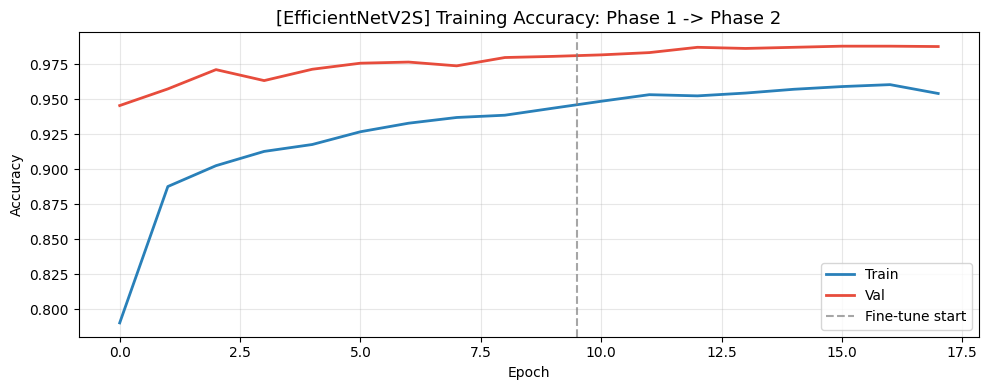

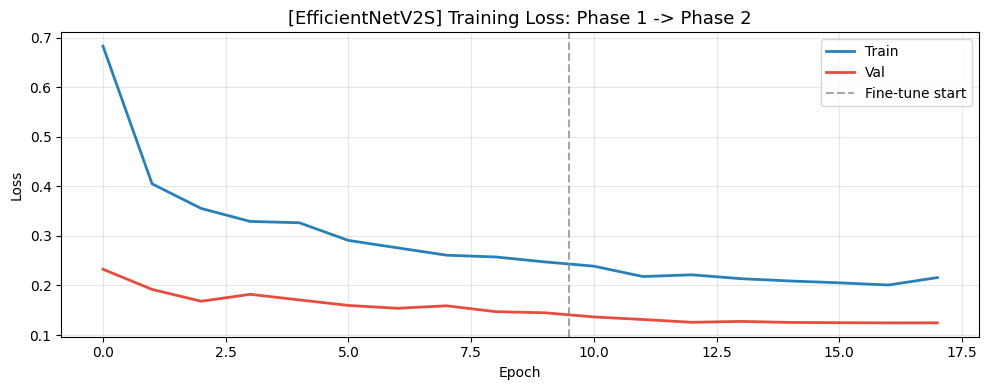

In [12]:
def plot_combined(h_fe, h_ft, model_name=MODEL_NAME):
    fe_len = len(h_fe.history['accuracy'])
    for metric, ylabel in [('accuracy','Accuracy'), ('loss','Loss')]:
        train = h_fe.history[metric] + h_ft.history[metric]
        val   = h_fe.history[f'val_{metric}'] + h_ft.history[f'val_{metric}']
        plt.figure(figsize=(10, 4))
        plt.plot(train, label='Train', color='#2980b9', lw=2)
        plt.plot(val,   label='Val',   color='#e74c3c', lw=2)
        plt.axvline(fe_len - 0.5, color='gray', ls='--', alpha=0.7, label='Fine-tune start')
        plt.xlabel('Epoch'); plt.ylabel(ylabel); plt.legend(); plt.grid(alpha=0.3)
        plt.title(f'[{model_name}] Training {ylabel}: Phase 1 -> Phase 2', fontsize=13)
        plt.tight_layout(); plt.show()

plot_combined(history_fe, history_ft)

## 9. Evaluation

In [14]:
best_model = keras.models.load_model(str(MODEL_DIR / 'best_ft.keras'))
test_loss, test_acc, test_top3 = best_model.evaluate(test_pipeline, verbose=1)
print(f'\nTest Accuracy:       {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'Test Top-3 Accuracy: {test_top3:.4f} ({test_top3*100:.2f}%)')
print(f'Test Loss:           {test_loss:.4f}')

58/58 ━━━━━━━━━━━━━━━━━━━━ 76s 746ms/step - accuracy: 0.9903 - loss: 0.1120 - top3_acc: 1.0000

Test Accuracy:       0.9848 (98.48%)
Test Top-3 Accuracy: 1.0000 (100.00%)
Test Loss:           0.1261


                 precision    recall  f1-score   support

 Apple__Healthy      0.964     0.988     0.976       245
  Apple__Rotten      0.989     0.968     0.978       278
Banana__Healthy      0.986     1.000     0.993       207
 Banana__Rotten      1.000     0.989     0.994       265
 Mango__Healthy      0.966     0.983     0.974       174
  Mango__Rotten      0.987     0.983     0.985       238
Orange__Healthy      0.995     0.981     0.988       207
 Orange__Rotten      0.987     0.991     0.989       233

       accuracy                          0.985      1847
      macro avg      0.984     0.985     0.985      1847
   weighted avg      0.985     0.985     0.985      1847



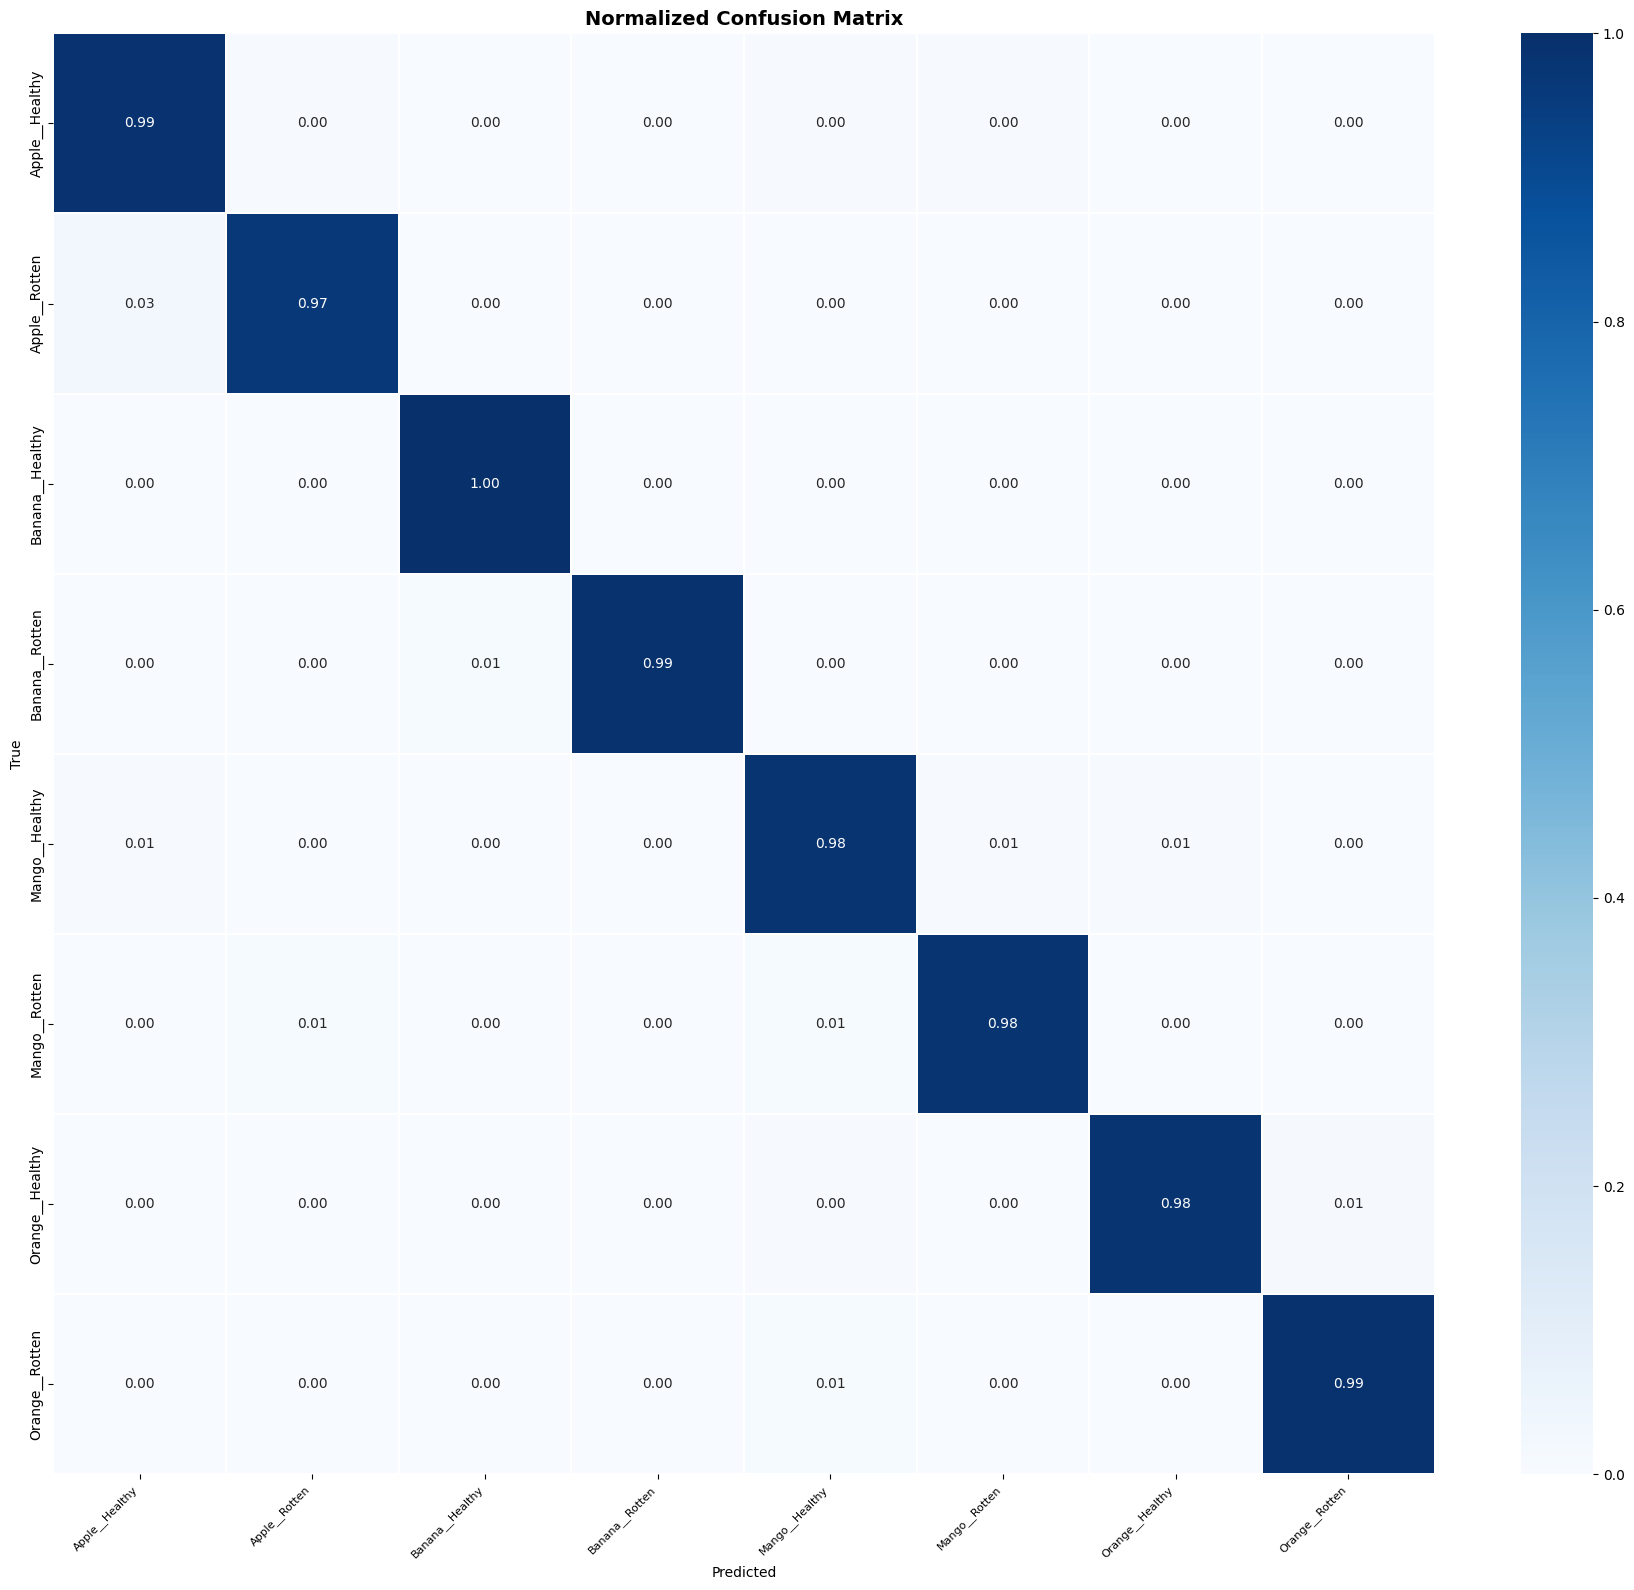

In [18]:
y_true, y_pred = [], []
for images, labels in test_pipeline:
    preds = best_model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=3))

cm_m  = confusion_matrix(y_true, y_pred)
cm_n  = cm_m.astype('float') / cm_m.sum(axis=1)[:, np.newaxis]
fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(cm_n, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, linewidths=0.3, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Normalized Confusion Matrix', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout(); plt.show()

## 10. Grad-CAM

Shows where the model looks when predicting. Important for validating that the model focuses on actual rot/disease areas and not the background.

In [21]:
def get_gradcam(model, img_array):

    last_conv = None

    # find last convolutional layer safely
    for layer in reversed(model.layers):

        try:
            shape = layer.output.shape

            if len(shape) == 4:
                last_conv = layer.name
                break

        except:
            continue

    print("Using conv layer:", last_conv)

    grad_model = keras.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:

        inputs = tf.cast(img_array, tf.float32)

        conv_out, preds = grad_model(inputs)

        pred_idx = tf.argmax(preds[0])

        class_ch = preds[:, pred_idx]

    grads = tape.gradient(class_ch, conv_out)

    pooled = tf.reduce_mean(grads, axis=(0, 1, 2))

    heatmap = conv_out[0] @ pooled[..., tf.newaxis]

    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)

    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

    return (
        heatmap.numpy(),
        CLASS_NAMES[pred_idx.numpy()],
        float(tf.reduce_max(preds))
    )

Saving model

In [22]:
best_model.save(str(MODEL_DIR / f'{MODEL_NAME.lower()}.keras'))
print(f'Saved: {MODEL_NAME.lower()}.keras')

meta = {
    'model_name': MODEL_NAME,
    'class_names': CLASS_NAMES,
    'num_classes': NUM_CLASSES,
    'img_size': list(IMG_SIZE),
    'test_accuracy': float(test_acc),
    'test_top3_accuracy': float(test_top3),
    'test_loss': float(test_loss)
}
with open(str(MODEL_DIR / 'results.json'), 'w') as f:
    json.dump(meta, f, indent=2)

print('\n========= RESULTS SUMMARY =========')
print(f'  Model:          {MODEL_NAME}')
print(f'  Test Accuracy:  {test_acc*100:.2f}%')
print(f'  Top-3 Accuracy: {test_top3*100:.2f}%')
print(f'  Test Loss:      {test_loss:.4f}')
print('===================================')

# Save training history
history_data = {
    'phase1': history_fe.history,
    'phase2': history_ft.history
}
with open(str(MODEL_DIR / f'{MODEL_NAME.lower()}_history.json'), 'w') as f:
    json.dump(history_data, f)
print('History saved.')

Saved: efficientnetv2s.keras

========= RESULTS SUMMARY =========
  Model:          EfficientNetV2S
  Test Accuracy:  98.48%
  Top-3 Accuracy: 100.00%
  Test Loss:      0.1261
History saved.


In [23]:
# Sanity check
loaded = keras.models.load_model(str(MODEL_DIR / 'fruit_disease_classifier.h5'))
for cls in CLASS_NAMES:
    imgs = list((TRAIN_DIR / cls).glob('*.jpg'))
    if imgs:
        img  = tf.keras.utils.load_img(imgs[0], target_size=tuple(meta['img_size']))
        arr  = effv2_preprocess(tf.keras.utils.img_to_array(img)[np.newaxis, ...])
        preds = loaded.predict(arr, verbose=0)[0]
        top3  = np.argsort(preds)[::-1][:3]
        print(f'True: {cls}')
        for i in top3:
            print(f'  {CLASS_NAMES[i]:35s} {preds[i]*100:.2f}%')
        print('Model export verified!')
        break

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/kaggle/working/models/fruit_disease_classifier.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [24]:
history_data = {
    "phase1": history_fe.history,
    "phase2": history_ft.history
}

with open(str(MODEL_DIR / f'{MODEL_NAME.lower()}_history.json'), 'w') as f:
    json.dump(history_data, f)

print("History saved.")

History saved.
